In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BIDS_DIR = Path('/data/ds-valuecapture')
subjects = [1, 2, 3]
sessions = [1, 2]

In [48]:
dfs = []

for sub in subjects:
    print(sub)
    for ses in sessions:
        func_dir = BIDS_DIR / f'sub-{sub:02d}' / f'ses-{ses}' / 'func'
        print(func_dir, func_dir.exists())
        for tsv in sorted(func_dir.glob(f'sub-{sub:02d}_ses-{ses}_task-valuecapture_run-*_events.tsv')):
            run = int(tsv.stem.split('run-')[1].split('_')[0])
            df = pd.read_csv(tsv, sep='\t')
            df['subject'] = sub
            df['session'] = ses
            df['run'] = run
            dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(dfs)} runs, {df.subject.nunique()} subjects')

1
/data/ds-valuecapture/sub-01/ses-1/func True
/data/ds-valuecapture/sub-01/ses-2/func True
2
/data/ds-valuecapture/sub-02/ses-1/func True
/data/ds-valuecapture/sub-02/ses-2/func True
3
/data/ds-valuecapture/sub-03/ses-1/func True
/data/ds-valuecapture/sub-03/ses-2/func True
Loaded 48 runs, 3 subjects


In [63]:
df['show_feedback'].value_counts()

show_feedback
True     10823
False    10781
Name: count, dtype: int64

In [49]:
trials.columns

Index(['trial_nr', 'onset', 'event_type', 'phase', 'response', 'nr_frames',
       'distractor_present', 'value_rank', 'target_orientation',
       'distractor_location', 'dot_presence', 'target_location',
       'correct_response', 'show_feedback', 'correct', 'earned_points',
       'distractor_color_rgb', 'bar_position', 'bar_orientation', 'rt',
       'onset_abs', 'duration', 'subject', 'session', 'run', 'condition',
       'rt_ms'],
      dtype='object')

In [50]:
# One row per trial: iti1 phase has rt and correct filled in
trials = df[df['event_type'] == 'iti1'].copy()

def condition(row):
    if not row['distractor_present']:
        return 'absent'
    return {0: 'low', 1:'medium', 2:'high'}[row['value_rank']]


trials['condition'] = trials.apply(condition, axis=1)
trials['rt_ms'] = trials['rt'] * 1000

print(trials['condition'].value_counts())

condition
medium    480
high      480
low       480
absent    480
Name: count, dtype: int64


In [70]:
trials.groupby(['condition'])['earned_points'].mean()

condition
absent      4.552083
high      408.622917
low         4.372917
medium     45.243750
Name: earned_points, dtype: float64

In [52]:
CONDITION_ORDER = ['absent', 'low', 'medium', 'high']

grp = ['subject', 'condition']
mean_rt  = trials[trials['correct'] == True].groupby(grp)['rt_ms'].mean().rename('mean_rt')
accuracy = trials.groupby(grp)['correct'].mean().rename('accuracy')

summary = pd.concat([mean_rt, accuracy], axis=1).reset_index()
summary['condition'] = pd.Categorical(summary['condition'], categories=CONDITION_ORDER, ordered=True)
summary = summary.sort_values(['subject', 'condition'])
summary

,subject,condition,mean_rt,accuracy
0,1,absent,981.404028,0.791139
2,1,low,980.974267,0.807692
3,1,medium,1002.228000,0.821192
1,1,high,999.669053,0.753165
4,2,absent,793.772529,0.94375
6,2,low,875.790566,0.955975
7,2,medium,830.622041,0.974843
5,2,high,930.703851,0.886076
8,3,absent,769.335763,0.90625
10,3,low,759.672974,0.875


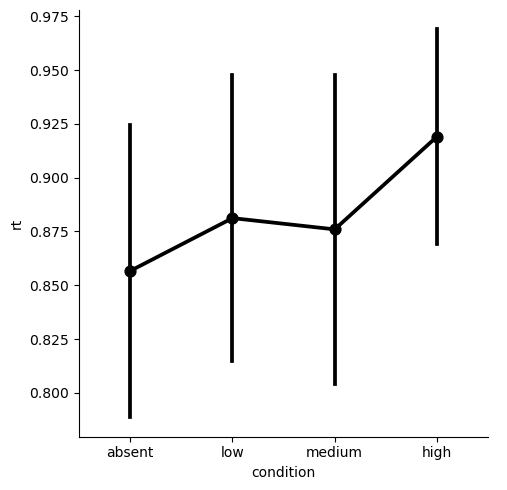

In [54]:
sns.catplot(x='condition', y='rt', data=trials.groupby(['subject', 'condition'])[['rt']].mean().reset_index(), order=CONDITION_ORDER, kind='point', errorbar='se', color='k')

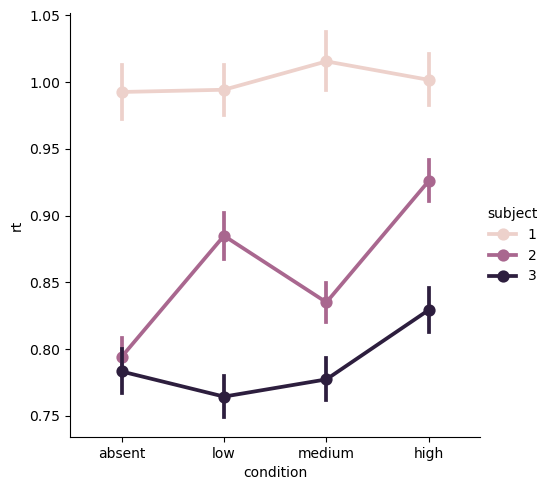

In [55]:
sns.catplot(x='condition', y='rt', data=trials, order=CONDITION_ORDER, kind='point', hue='subject', errorbar='se')

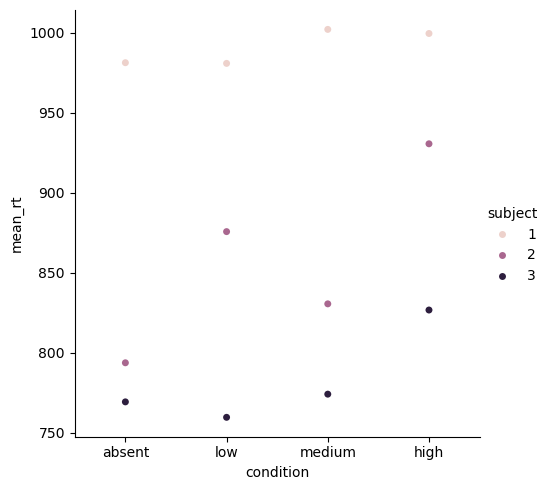

In [ ]:
sns.catplot(x='condition', y='mean_rt', data=summary, order=CONDITION_ORDER, kind='swarm', hue='subject')

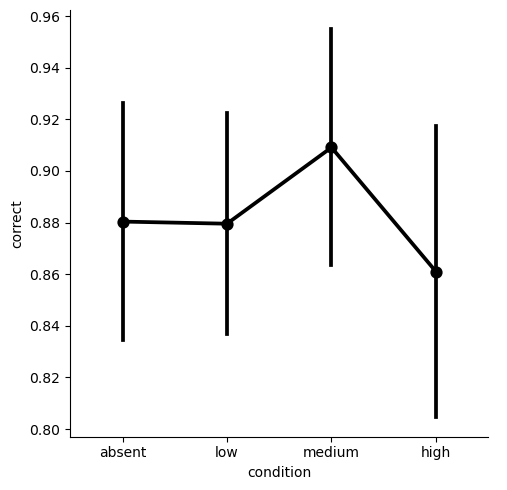

In [59]:
sns.catplot(x='condition', y='correct', data=trials.groupby(['subject', 'condition'])[['correct']].mean().reset_index(), order=CONDITION_ORDER, kind='point', errorbar='se', color='k')

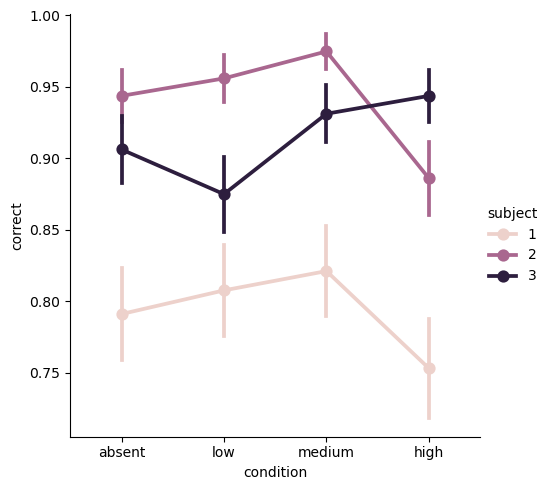

In [57]:
sns.catplot(x='condition', y='correct', data=trials, order=CONDITION_ORDER, kind='point', hue='subject', errorbar='se')

In [58]:
import hddm

ModuleNotFoundError: No module named 'hddm'

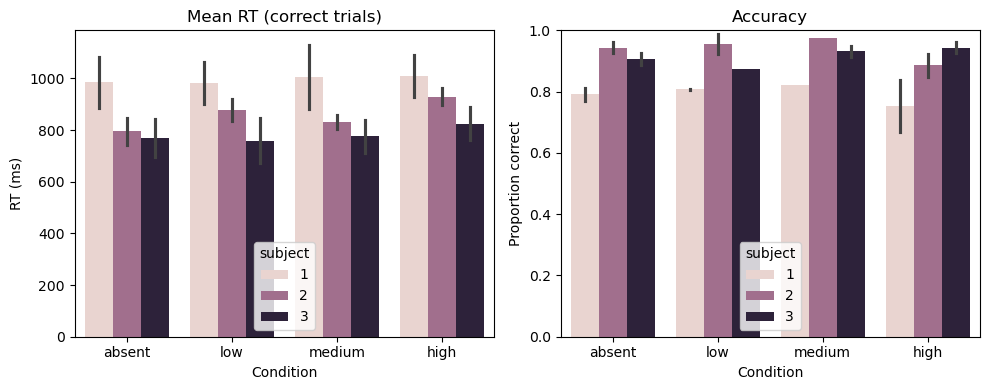

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=summary, x='condition', y='mean_rt', hue='subject',
            order=CONDITION_ORDER, ax=axes[0])
axes[0].set_title('Mean RT (correct trials)')
axes[0].set_ylabel('RT (ms)')
axes[0].set_xlabel('Condition')

sns.barplot(data=summary, x='condition', y='accuracy', hue='subject',
            order=CONDITION_ORDER, ax=axes[1])
axes[1].set_title('Accuracy')
axes[1].set_ylabel('Proportion correct')
axes[1].set_xlabel('Condition')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# Grand mean across sessions
grand = summary.groupby(['subject', 'condition'])[['mean_rt', 'accuracy']].mean().round(1)
grand

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_13527/574987014.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grand = summary.groupby(['subject', 'condition'])[['mean_rt', 'accuracy']].mean().round(1)


mean_rt  accuracy
subject condition                   
1       absent       985.4  0.790865
        rank-0       982.3  0.807661
        rank-1      1006.2  0.821215
        rank-2      1009.9  0.752083
2       absent       794.8   0.94375
        rank-0       877.5  0.955775
        rank-1       830.8  0.974842
        rank-2       929.3  0.886076
3       absent       770.9   0.90625
        rank-0       759.7     0.875
        rank-1       775.4   0.93125
        rank-2       825.5   0.94375